In [15]:
!zip -r /content/etrike_yolo_final_results /content/etrike_yolo_final_results

  adding: content/etrike_yolo_final_results/ (stored 0%)
  adding: content/etrike_yolo_final_results/detect/ (stored 0%)
  adding: content/etrike_yolo_final_results/detect/etrike_model_3/ (stored 0%)
  adding: content/etrike_yolo_final_results/detect/etrike_model_3/train_batch1.jpg (deflated 7%)
  adding: content/etrike_yolo_final_results/detect/etrike_model_3/train_batch4321.jpg (deflated 12%)
  adding: content/etrike_yolo_final_results/detect/etrike_model_3/val_batch1_labels.jpg (deflated 12%)
  adding: content/etrike_yolo_final_results/detect/etrike_model_3/val_batch2_labels.jpg (deflated 12%)
  adding: content/etrike_yolo_final_results/detect/etrike_model_3/val_batch1_pred.jpg (deflated 12%)
  adding: content/etrike_yolo_final_results/detect/etrike_model_3/results.png (deflated 9%)
  adding: content/etrike_yolo_final_results/detect/etrike_model_3/confusion_matrix_normalized.png (deflated 36%)
  adding: content/etrike_yolo_final_results/detect/etrike_model_3/val_batch2_pred.jpg (def

In [ ]:
import shutil
import os

# Source: The local folder where YOLO saved all your graphs, weights, and CSVs
source_runs = '/content/etrike_yolo_dataset'

# Destination: A new folder in your Google Drive
drive_backup = '/content/drive/MyDrive/final_dataset'

print("Backing up training results to Google Drive...")

# Copy the entire folder over
if not os.path.exists(drive_backup):
    shutil.copytree(source_runs, drive_backup)
    print(f"✅ Success! All your charts, matrices, and weights are saved at: {drive_backup}")
else:
    print(f"⚠️ Backup folder already exists. Please rename or delete {drive_backup} first.")

Backing up training results to Google Drive...
✅ Success! All your charts, matrices, and weights are saved at: /content/drive/MyDrive/final_dataset


In [4]:
from google.colab import drive

# Mount Google Drive (if you haven't already in this session)
#drive.mount('/content/drive')

# Copy the folder to Colab's local storage recursively (-r)
print("Copying dataset to local storage... (This may take a moment depending on size)")
!cp -r /content/drive/MyDrive/etrike_yolo_final_results /content/etrike_yolo_final_results



Copying dataset to local storage... (This may take a moment depending on size)


gdrive and ultralytics setup

In [ ]:
# SETUP AND YAML VERIFICATION
from google.colab import drive
import os
import yaml

# Mount Google Drive
drive.mount('/content/drive')

# Install the latest ultralytics package
%pip install -q ultralytics
import ultralytics
from ultralytics import YOLO

ultralytics.checks()

# Verify and create data.yaml for your E-bike dataset
dataset_path = '/content/drive/MyDrive/etrike_yolo_dataset'
yaml_path = os.path.join(dataset_path, 'data.yaml')

yaml_data = {
    'train': os.path.join(dataset_path, 'train/images'),
    'val': os.path.join(dataset_path, 'val/images'),
    'test': os.path.join(dataset_path, 'test/images'),
    'nc': 1,
    'names': ['E-bike']
}

with open(yaml_path, 'w') as f:
    yaml.dump(yaml_data, f, sort_keys=False)

print(f"\nVerified! data.yaml is ready at: {yaml_path}")

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.7/112.6 GB disk)

Verified! data.yaml is ready at: /content/drive/MyDrive/etrike_yolo_dataset/data.yaml


dataset importing

In [ ]:
print("Copying dataset from Drive to local Colab storage... (This might take a minute)")
!cp -r /content/drive/MyDrive/etrike_yolo_dataset /content/etrike_yolo_dataset
print("Copy complete!")
local_dataset_path = '/content/etrike_yolo_dataset'
yaml_path = os.path.join(local_dataset_path, 'data.yaml')

Copying dataset from Drive to local Colab storage... (This might take a minute)
Copy complete!


Modelling

In [ ]:
#TRAIN 3 DIFFERENT MODELS
from ultralytics import YOLO

model_path = "yolo26n.pt"

print("--- STARTING MODEL 1 TRAINING ---")
model1 = YOLO(model_path)
model1.train(
    data=yaml_path,
    epochs=25,
    imgsz=640,
    optimizer='AdamW',
    batch=4,
    lr0=0.01,
    name='etrike_model_1'
)

print("\n--- STARTING MODEL 2 TRAINING ---")
model2 = YOLO(model_path)
model2.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    optimizer='SGD',
    batch=20,
    lr0=0.001,
    name='etrike_model_2'
)

print("\n--- STARTING MODEL 3 TRAINING ---")
model3 = YOLO(model_path)
model3.train(
    data=yaml_path,
    epochs=40,
    imgsz=640,
    optimizer='auto',
    batch=-1, # Auto-batching
    lr0=0.0001,
    name='etrike_model_3'
)
print("\nAll 3 models have completed training!")

--- STARTING MODEL 1 TRAINING ---
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/etrike_yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=etrike_model_1, nbs=64, nms=False, opset=None, optimize=False, optimizer

Model 1 evaluation

In [9]:
from ultralytics import YOLO

# Load the 'best' weights from your most successful training run
best_model = YOLO('/content/etrike_yolo_final_results/detect/etrike_model_1/weights/best.pt')

# Run the validation sequence specifically on the 'test' split
print("Evaluating model on the unseen TEST dataset...")
test_metrics = best_model.val(split='test')

Evaluating model on the unseen TEST dataset...
Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 0.2±0.1 MB/s, size: 103.3 KB)
val: Scanning /content/drive/MyDrive/etrike_yolo_dataset/test/labels... 329 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 329/329 2.4it/s 2:16
val: New cache created: /content/drive/MyDrive/etrike_yolo_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 3.7it/s 5.7s
                   all        329       1159      0.936      0.914       0.97      0.795
Speed: 2.5ms preprocess, 4.4ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val


Model 2 evaluation

In [10]:
from ultralytics import YOLO

# Load the 'best' weights from your most successful training run
best_model = YOLO('/content/etrike_yolo_final_results/detect/etrike_model_2/weights/best.pt')

# Run the validation sequence specifically on the 'test' split
print("Evaluating model on the unseen TEST dataset...")
test_metrics = best_model.val(split='test')

Evaluating model on the unseen TEST dataset...
Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.4 ms, read: 49.5±18.8 MB/s, size: 104.1 KB)
val: Scanning /content/drive/MyDrive/etrike_yolo_dataset/test/labels.cache... 329 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 329/329 115.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 2.8it/s 7.4s
                   all        329       1159      0.878      0.826      0.927      0.744
Speed: 4.4ms preprocess, 5.2ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /content/runs/detect/val2


Model 3 evaluation

In [11]:
from ultralytics import YOLO

# Load the 'best' weights from your most successful training run
best_model = YOLO('/content/etrike_yolo_final_results/detect/etrike_model_3/weights/best.pt')

# Run the validation sequence specifically on the 'test' split
print("Evaluating model on the unseen TEST dataset...")
test_metrics = best_model.val(split='test')

Evaluating model on the unseen TEST dataset...
Ultralytics 8.4.15 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.3 ms, read: 47.7±18.2 MB/s, size: 120.8 KB)
val: Scanning /content/drive/MyDrive/etrike_yolo_dataset/test/labels.cache... 329 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 329/329 138.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 3.7it/s 5.6s
                   all        329       1159      0.967       0.94      0.985      0.833
Speed: 2.4ms preprocess, 4.6ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val3


Confusion matrix

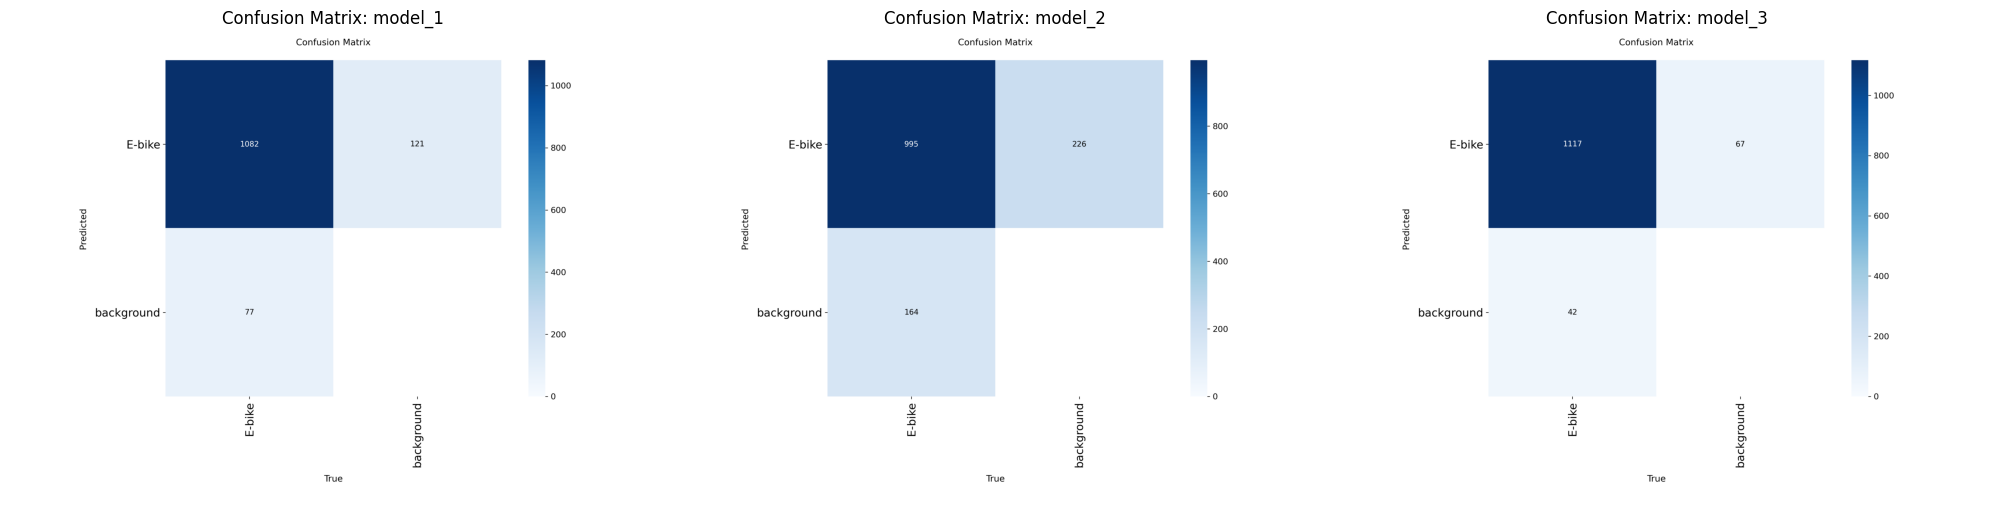

In [14]:
# DISPLAY CONFUSION MATRICES
import matplotlib.pyplot as plt
import cv2
import os

runs = ['val', 'val2', 'val3']
base_run_dir = '/content/runs/detect'
models = ['model_1', 'model_2', 'model_3']
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, run_name in enumerate(runs):
    cm_path = os.path.join(base_run_dir, run_name, 'confusion_matrix.png')
    model_name = models[i]
    if os.path.exists(cm_path):
        img = cv2.imread(cm_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(f"Confusion Matrix: {model_name}")
        axes[i].axis('off')
    else:
        axes[i].set_title(f"Matrix not found for {run_name}")
        axes[i].axis('off')

plt.tight_layout()
plt.show()

Performance tables

In [8]:
# GENERATE PERFORMANCE TABLES
import pandas as pd
import numpy as np

# Hyperparameter Table
hyperparams_data = {
    'Model': ['Model 1', 'Model 2', 'Model 3'],
    'Epochs': [25, 30, 40],
    'Image Size': [640, 640, 640],
    'Optimizer': ['AdamW', 'SGD', 'auto'],
    'Batch Size': [4, 20, '-1 (Auto)'],
    'Learning Rate': [0.01, 0.001, 0.0001]
}
df_hyperparams = pd.DataFrame(hyperparams_data)

# Metrics Table
# Note: In a live run, you would extract these using model.val(),
# but YOLO automatically saves them in a results.csv file during training.
metrics_data = []

for run in runs:
    csv_path = os.path.join(base_run_dir, run, 'results.csv')
    if os.path.exists(csv_path):
        # Read the CSV and strip whitespace from column names
        df_res = pd.read_csv(csv_path)
        df_res.columns = df_res.columns.str.strip()

        # Get the final epoch's metrics
        final_epoch = df_res.iloc[-1]

        # Calculate F1 Score: 2 * (Precision * Recall) / (Precision + Recall)
        p = final_epoch['metrics/precision(B)']
        r = final_epoch['metrics/recall(B)']
        f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

        metrics_data.append({
            'Model': run,
            'mAP50': round(final_epoch['metrics/mAP50(B)'], 4),
            'Precision': round(p, 4),
            'Recall': round(r, 4),
            'F1 Score': round(f1, 4)
        })
    else:
        metrics_data.append({'Model': run, 'mAP50': 'N/A', 'Precision': 'N/A', 'Recall': 'N/A', 'F1 Score': 'N/A'})

df_metrics = pd.DataFrame(metrics_data)

print("--- HYPERPARAMETER SETTINGS ---")
display(df_hyperparams)
print("\n--- MODEL PERFORMANCE METRICS ---")
display(df_metrics)

--- HYPERPARAMETER SETTINGS ---


,Model,Epochs,Image Size,Optimizer,Batch Size,Learning Rate
0,Model 1,25,640,AdamW,4,0.0100
1,Model 2,30,640,SGD,20,0.0010
2,Model 3,40,640,auto,-1 (Auto),0.0001



--- MODEL PERFORMANCE METRICS ---


,Model,mAP50,Precision,Recall,F1 Score
0,etrike_model_1,0.9732,0.9351,0.9182,0.9266
1,etrike_model_2,0.9267,0.8844,0.8238,0.8530
2,etrike_model_3,0.9862,0.9577,0.9452,0.9514
